# U-Net Dwelling Segmentation — Melusi Informal Settlement

**Project:** MIT 808 Capstone — Small-Area Population Estimation  
**Pipeline owner:** Kampamba Chanda  

---

## Approach

- **Architecture:** U-Net with ResNet34 encoder (pretrained on ImageNet)
- **Input:** 512 × 512 × 3 RGB tiles from drone orthophoto (3 cm/px)
- **Output:** 512 × 512 × 1 binary mask (dwelling / background)
- **Loss:** Focal + Dice + Boundary — boundary pixels upweighted 3× via 3px dilation to sharpen dwelling edges at 6.3% class fraction
- **Normalisation:** ImageNet statistics (matching pretrained encoder expectations)
- **Scheduler:** CosineAnnealingWarmRestarts (T₀=15) replacing ReduceLROnPlateau
- **Encoder:** Frozen for first 5 epochs, unfrozen at epoch 6 with optimizer and scheduler reset
- **Split:** Block-stratified — entire blocks held out for val/test to prevent spatial leakage
- **Augmentations:** Horizontal/vertical flip, 90° rotations, brightness/contrast jitter
- **Inference:** Test-time augmentation (8×) applied at evaluation and full-settlement inference

### Split strategy

Spatial autocorrelation means random tile splits leak information — adjacent tiles in the
same block share roof texture and shadow context. We split at the **block level**:

| Set | Blocks | Tiles | Purpose |
|-----|--------|-------|---------|
| Train | 2, 5, 6, 7, 9, 10, 12 | ~1,618 (incl. bronze) | Model fitting |
| Val | 3, 4 | ~388 | Epoch selection, early stopping |
| Test | 1, 8 | ~225 | Final evaluation, never seen during training |

Early stopping monitors validation Dice (patience = 20).

### Label provenance — SAM + GOB fusion

Training masks were generated by a two-stage hybrid pipeline:

1. **Google Open Buildings v3 (GOB)** footprints rasterised to 3cm/px, classified into confidence tiers based on LiDAR Z-distribution agreement
2. **Segment Anything Model (SAM ViT-H)** run on all 8,109 tiles to produce roof-level instance masks
3. **Fusion:** SAM masks gated by dilated GOB footprints — SAM detections outside any GOB footprint are suppressed; confirmed detections are retained at full confidence

| Tier | Criteria | Training role |
|------|----------|---------------|
| Gold | >80% high-confidence pixels | Full weight, all epochs |
| Silver | 50–80% high-confidence pixels | Full weight, all epochs |
| Bronze | <50% high-confidence pixels | 0.3 sample weight |
| Empty | No dwelling pixels | 15% sampled as negatives |

### Training runs summary

| Run | Key configuration | Best val metric | Test IoU (TTA) |
|-----|-------------------|-----------------|----------------|
| 1 | Curriculum + mixed precision, ReduceLROnPlateau | IoU 0.421 (ep 23) | — |
| 2 | Longer patience (15), 80 epochs | — | 0.352 |
| 3 | Boundary loss, cosine LR, encoder freeze | — | 0.364 |
| 4 ★ | SAM+GOB fused labels, full config | Dice ~0.30 (ep 9) | 0.365 |

Run 4 (`kc_unet_run4.ipynb`) is the submitted model. Test IoU reported with 8× TTA on held-out blocks 1 and 8.

# Phase 0: Environment Setup

In [ ]:
import subprocess, sys, os
from google.colab import drive, userdata

drive.mount('/content/drive')

TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

REPO_DIR = '/content/mit808-2026-project-data-insight-drivers'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git
else:
    print("Repo already cloned")

os.chdir(REPO_DIR)
!git fetch origin master
!git merge origin/master -m "Sync with master"
!git checkout kc/unet

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'segmentation-models-pytorch', 'albumentations'
])

sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("Bootstrap complete")


Mounted at /content/drive
Cloning into 'mit808-2026-project-data-insight-drivers'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 84 (delta 11), reused 13 (delta 9), pack-reused 59 (from 1)
Receiving objects: 100% (84/84), 8.81 MiB | 31.12 MiB/s, done.
Resolving deltas: 100% (21/21), done.
From https://github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers
 * branch            master     -> FETCH_HEAD
Already up to date.
Branch 'kc/unet' set up to track remote branch 'kc/unet' from 'origin'.
Switched to a new branch 'kc/unet'


## Config

In [2]:
import os, json
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import shutil

LOCAL_TILES       = "/content/local_tiles/image_tiles"
LOCAL_MASK_TILES  = "/content/local_tiles/mask_tiles"
LOCAL_FUSED_MASKS = "/content/local_tiles/fused_mask_tiles"

class Config:
    DRIVE_BASE      = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data"
    PROCESSED_DIR   = f"{DRIVE_BASE}/processed"
    BLOCK_RASTERS   = f"{PROCESSED_DIR}/smoothBlocks/block_rasters"
    TILES_DIR       = LOCAL_TILES
    MASK_TILES_DIR  = LOCAL_MASK_TILES
    FUSED_TILES_DIR = LOCAL_FUSED_MASKS
    TILE_INDEX      = f"{PROCESSED_DIR}/tile_index.csv"
    CHECKPOINT_DIR  = f"{PROCESSED_DIR}/checkpoints_run4"
    PIXEL_SIZE      = 0.03
    MASKS_DIR           = f"{PROCESSED_DIR}/masks"
    HIGH_CONF_MASKS_DIR = f"{PROCESSED_DIR}/masks_high_conf"
    FOOTPRINT_GPKG      = f"{PROCESSED_DIR}/footprint_confidence.gpkg"

    # Drive paths for copying
    DRIVE_IMAGE_TILES = f"{PROCESSED_DIR}/smoothBlocks/melusi_tiles"
    DRIVE_MASK_TILES  = f"{PROCESSED_DIR}/smoothBlocks/melusi_mask_tiles"
    DRIVE_FUSED_MASKS = f"{PROCESSED_DIR}/smoothBlocks/melusi_fused_mask_tiles"

    # ── Architecture ───────────────────────────────────────────────────────
    ENCODER         = "resnet34"    # Encoder backbone (any smp-compatible name)
    ENCODER_WEIGHTS = "imagenet"    # Pretrained weights source
    IN_CHANNELS     = 3             # RGB input
    CLASSES         = 1             # Binary segmentation (dwelling / background)
    TILE_SIZE       = 512           # Spatial dimensions of input tiles

    # ── ImageNet normalisation ───────────────────────────────────────────────
    IMG_MEAN = [0.485, 0.456, 0.406]   # ImageNet RGB channel means
    IMG_STD  = [0.229, 0.224, 0.225]   # ImageNet RGB channel stds

    # ── Loss: Focal + Dice + Boundary weighting ──────────────────────────────
    FOCAL_ALPHA       = 0.75          # Weight for positive (dwelling) class
    FOCAL_GAMMA       = 2.0           # Focusing parameter (0 = standard BCE)
    DICE_SMOOTH       = 1.0           # Laplace smoothing for Dice denominator
    LOSS_FOCAL_W      = 0.5           # Blend: 0.5 * focal + 0.5 * dice
    BOUNDARY_DILATION = 3
    BOUNDARY_WEIGHT   = 3.0

    # ── Early stopping ──────────────────────────────────────────────────────
    EARLY_STOP_METRIC = "dice"       # "iou" or "loss"
    PATIENCE          = 20           # Give bronze phase room

    # ── Curriculum learning ──────────────────────────────────────────────────
    CURRICULUM_EPOCH      = 0       # Epoch at which bronze tiles enter training
    TIER_GOLD_THRESHOLD   = 0.9     # tile_confidence >= this then gold
    TIER_SILVER_THRESHOLD = 0.4     # tile_confidence >= this then silver
    LAMBDA_MIN            = 1.0

    # ── Encoder freeze ───────────────────────────────────────────────────────
    ENCODER_FREEZE_EPOCHS = 5

    # ── Scheduler: CosineAnnealingWarmRestarts ────────────────────────────────
    T_0     = 15
    T_MULT  = 1
    ETA_MIN = 1e-6

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE    = 32             # 4 for T4 (16 GB), 8 for A100 (40 GB)
    NUM_WORKERS   = 8              # DataLoader workers
    LEARNING_RATE = 1e-4           # Initial AdamW learning rate
    WEIGHT_DECAY  = 1e-4           # L2 regularisation
    EPOCHS        = 100            # No. Epochs

    # ── Data split ───────────────────────────────────────────────────────────
    TRAIN_BLOCKS = ["block_12", "block_10", "block_6", "block_3",
                    "block_4",  "block_2",  "block_7", "block_9"]
    VAL_BLOCKS   = ["block_8", "block_5"]
    TEST_BLOCKS  = ["block_1", "block_11"]

    # ── Tile filtering ─────────────────────────────────────────────────────
    MIN_DWELLING_FRAC = 0.001      # Minimum dwelling fraction for positive tiles
    EMPTY_SAMPLE_FRAC = 0.15       # Fraction of empty tiles included as negatives
    EMPTY_SEED        = 42         # Random seed for empty tile sampling

    # ── Device ─────────────────────────────────────────────────────────────
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

assert cfg.DEVICE == "cuda", (
    "GPU required. Runtime > Change runtime type > GPU.")

print(f"Device: {cfg.DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"\nRun 4 — fused SAM+GOB masks (all Run 3 fixes retained):")
print(f"  Mask source:  fused_mask_path (SAM+GOB) where available, else mask_path")
print(f"  Checkpoint:   {cfg.CHECKPOINT_DIR}")
print(f"  F1  Val blocks:         {cfg.VAL_BLOCKS}")
print(f"  F2  Curriculum epoch:   {cfg.CURRICULUM_EPOCH} (bypassed)")
print(f"  F3  Empty sample frac:  {cfg.EMPTY_SAMPLE_FRAC}")
print(f"  F4  Encoder freeze:     first {cfg.ENCODER_FREEZE_EPOCHS} epochs")
print(f"  F5  Scheduler:          CosineWarmRestarts(T_0={cfg.T_0})")
print(f"  F6  Early stop metric:  {cfg.EARLY_STOP_METRIC}")
print(f"  F7  Boundary loss:      {cfg.BOUNDARY_DILATION}px @ {cfg.BOUNDARY_WEIGHT}x")
print(f"  LR: {cfg.LEARNING_RATE} | Batch: {cfg.BATCH_SIZE} | Epochs: {cfg.EPOCHS}")

Device: cuda (NVIDIA A100-SXM4-40GB)

Run 4 — fused SAM+GOB masks (all Run 3 fixes retained):
  Mask source:  fused_mask_path (SAM+GOB) where available, else mask_path
  Checkpoint:   /content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/checkpoints_run4
  F1  Val blocks:         ['block_8', 'block_5']
  F2  Curriculum epoch:   0 (bypassed)
  F3  Empty sample frac:  0.15
  F4  Encoder freeze:     first 5 epochs
  F5  Scheduler:          CosineWarmRestarts(T_0=15)
  F6  Early stop metric:  dice
  F7  Boundary loss:      3px @ 3.0x
  LR: 0.0001 | Batch: 32 | Epochs: 100


# Phase 1: Load Tiles to SSD

In [3]:
import threading, time

ignore = shutil.ignore_patterns("*.gsheet", "*.gdoc", "*.gslides")
_done = {}

def _progress(label, dst, total):
    start = time.time()
    while not _done.get(label, False):
        elapsed = int(time.time() - start)
        n = len([f for f in os.listdir(dst) if f.endswith(".tif")]) if os.path.exists(dst) else 0
        print(f"  [{elapsed:>4}s] {label}: {n:,}/{total:,} files", flush=True)
        time.sleep(15)

# Copy image tiles, old masks, and fused masks to SSD
copies = [
    ("image_tiles", cfg.DRIVE_IMAGE_TILES, LOCAL_TILES),
    ("mask_tiles",  cfg.DRIVE_MASK_TILES,  LOCAL_MASK_TILES),
    ("fused_masks", cfg.DRIVE_FUSED_MASKS, LOCAL_FUSED_MASKS),
]

for label, src_dir, dst_dir in copies:
    _done[label] = False
    if not os.path.exists(dst_dir):
        total = len([f for f in os.listdir(src_dir) if f.endswith(".tif")])
        t = threading.Thread(target=_progress,
            args=(label, dst_dir, total), daemon=True)
        t.start()
        shutil.copytree(src_dir, dst_dir, ignore=ignore)
        _done[label] = True
        print(f"  {label} done.")
    else:
        _done[label] = True
        print(f"  {label} already on SSD.")

local_img   = len([f for f in os.listdir(LOCAL_TILES) if f.endswith(".tif")])
local_mask  = len([f for f in os.listdir(LOCAL_MASK_TILES) if f.endswith(".tif")])
local_fused = len([f for f in os.listdir(LOCAL_FUSED_MASKS) if f.endswith(".tif")])
print(f"\nImage tiles on SSD: {local_img:,}")
print(f"Old masks on SSD:   {local_mask:,}")
print(f"Fused masks on SSD: {local_fused:,}")

# ── Rewrite tile_index paths to local SSD ────────────────────────────────────
tile_index = pd.read_csv(cfg.TILE_INDEX)

# Normalise block column
if "Block_id" in tile_index.columns and "block_id" not in tile_index.columns:
    tile_index["block_id"] = tile_index["Block_id"]

# Rewrite Drive paths to local SSD paths
tile_index["tile_path"] = tile_index["tile_path"].str.replace(
    cfg.DRIVE_IMAGE_TILES, LOCAL_TILES, regex=False)
tile_index["mask_path"] = tile_index["mask_path"].str.replace(
    cfg.DRIVE_MASK_TILES, LOCAL_MASK_TILES, regex=False)

if "fused_mask_path" in tile_index.columns:
    tile_index["fused_mask_path"] = tile_index["fused_mask_path"].str.replace(
        cfg.DRIVE_FUSED_MASKS, LOCAL_FUSED_MASKS, regex=False)

# ── THE KEY SWAP: use fused masks where available ────────────────────────────
if "fused_mask_path" in tile_index.columns:
    has_fused = tile_index["fused_mask_path"].notna()
    fused_exists = tile_index.loc[has_fused, "fused_mask_path"].apply(os.path.exists)
    n_swap = fused_exists.sum()
    tile_index.loc[has_fused & fused_exists.reindex(tile_index.index, fill_value=False),
                   "mask_path"] = tile_index["fused_mask_path"]
    print(f"\nMask swap: {n_swap:,} tiles using fused masks, "
          f"{len(tile_index) - n_swap:,} using old GOB masks")
else:
    print("\nWARNING: No fused_mask_path column found — using old masks only!")

# Recalculate dwelling_fraction from actual mask content
# (fused masks have different coverage than old masks)
print("Recalculating dwelling_fraction from swapped masks...")
new_fracs = []
new_px    = []
for _, row in tile_index.iterrows():
    mp = row["mask_path"]
    if pd.notna(mp) and os.path.exists(str(mp)):
        with rasterio.open(mp) as s:
            arr = s.read(1)
            px = (arr > 0).sum()
            new_fracs.append(px / arr.size)
            new_px.append(int(px))
    else:
        new_fracs.append(0.0)
        new_px.append(0)

tile_index["dwelling_fraction"]    = new_fracs
tile_index["dwelling_pixel_count"] = new_px
tile_index["has_mask"] = tile_index["mask_path"].apply(
    lambda p: pd.notna(p) and os.path.exists(str(p)))

# Save locally (don't overwrite Drive version)
tile_index.to_csv("/content/tile_index_run4.csv", index=False)
cfg.TILE_INDEX = "/content/tile_index_run4.csv"

n_dwelling = (tile_index["dwelling_fraction"] >= 0.001).sum()
print(f"Tiles with dwelling signal (frac>=0.001): {n_dwelling:,} of {len(tile_index):,}")
print(f"Mean dwelling fraction: {tile_index["dwelling_fraction"].mean():.4f}")
print(f"First tile exists: {os.path.exists(tile_index["tile_path"].iloc[0])}")
print(f"First mask exists: {os.path.exists(str(tile_index["mask_path"].iloc[0]))}")

  [   0s] image_tiles: 0/8,109 files
  [  15s] image_tiles: 13/8,109 files
  [  30s] image_tiles: 28/8,109 files
  [  45s] image_tiles: 45/8,109 files
  [  60s] image_tiles: 60/8,109 files
  [  75s] image_tiles: 78/8,109 files
  [  90s] image_tiles: 83/8,109 files
  [ 105s] image_tiles: 83/8,109 files
  [ 120s] image_tiles: 83/8,109 files
  [ 135s] image_tiles: 83/8,109 files
  [ 150s] image_tiles: 83/8,109 files
  [ 165s] image_tiles: 83/8,109 files
  [ 180s] image_tiles: 83/8,109 files
  [ 195s] image_tiles: 83/8,109 files
  [ 210s] image_tiles: 83/8,109 files
  [ 225s] image_tiles: 83/8,109 files
  [ 240s] image_tiles: 84/8,109 files
  [ 255s] image_tiles: 84/8,109 files
  [ 270s] image_tiles: 84/8,109 files
  [ 285s] image_tiles: 84/8,109 files
  [ 300s] image_tiles: 84/8,109 files
  [ 315s] image_tiles: 84/8,109 files
  [ 330s] image_tiles: 84/8,109 files
  [ 345s] image_tiles: 84/8,109 files
  [ 360s] image_tiles: 84/8,109 files
  [ 375s] image_tiles: 84/8,109 files
  [ 390s] ima

# Phase 2: Dataset & Augmentations

In [4]:
# ============================================================================
# DATASET
# ============================================================================

from scipy.ndimage import binary_dilation
import torch.nn.functional as F_nn

class MelusiTileDataset(Dataset):
    """
    Returns (image, mask, boundary_mask) tuples.

    boundary_mask: dilated ring around mask edges, used by FocalDiceBoundaryLoss
    to upweight hard boundary pixels (F7). Computed from the binary mask on the fly.
    """

    def __init__(self, tile_df, cfg, transform=None):
        self.records  = tile_df.reset_index(drop=True)
        self.cfg      = cfg
        self.transform = transform
        # Structuring element for boundary dilation (F7)
        r = cfg.BOUNDARY_DILATION
        y, x = np.ogrid[-r:r+1, -r:r+1]
        self.struct = (x**2 + y**2 <= r**2)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]

        with rasterio.open(row["tile_path"]) as src:
            img = src.read([1, 2, 3])
        img = np.moveaxis(img, 0, -1).astype(np.float32)  # (H, W, 3)

        with rasterio.open(row["mask_path"]) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        else:
            img  = torch.from_numpy(img).permute(2, 0, 1) / 255.0
            mask = torch.from_numpy(mask)

        mask = mask.unsqueeze(0)  # (1, H, W)

        # ── Boundary mask (F7) ──
        mask_np  = mask.squeeze(0).numpy().astype(bool)
        dilated  = binary_dilation(mask_np, structure=self.struct)
        boundary = (dilated & ~mask_np).astype(np.float32)  # ring outside edges
        boundary = torch.from_numpy(boundary).unsqueeze(0)  # (1, H, W)

        return img, mask, boundary


# ============================================================================
# AUGMENTATIONS
# ============================================================================

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=cfg.IMG_MEAN, std=cfg.IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=cfg.IMG_MEAN, std=cfg.IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])


# ============================================================================
# TILE INDEX + SPLITS
# ============================================================================

tile_df = pd.read_csv(cfg.TILE_INDEX)
tile_df = tile_df[tile_df["mask_path"].notna()].copy()
tile_df = tile_df[tile_df["mask_path"].apply(os.path.exists)].copy()

if "confidence_tier" not in tile_df.columns:
    tile_df["confidence_tier"] = "gold"
    tile_df["tile_confidence"] = 1.0
if "tile_confidence" not in tile_df.columns:
    tile_df["tile_confidence"] = 1.0

print(f"Total tiles with valid masks: {len(tile_df):,}")
print("\nConfidence tier distribution (all blocks):")
print(tile_df["confidence_tier"].value_counts().to_string())

# ── Training pool: all labeled tiles + capped negatives (F2, F3) ──
positives = tile_df[
    (tile_df["Block_id"].isin(cfg.TRAIN_BLOCKS)) &
    (tile_df["dwelling_fraction"] >= cfg.MIN_DWELLING_FRAC) &
    (tile_df["confidence_tier"].isin(["gold", "silver", "bronze"]))  # F2: all tiers
].copy()

empties = tile_df[
    (tile_df["Block_id"].isin(cfg.TRAIN_BLOCKS)) &
    (tile_df["dwelling_fraction"] < cfg.MIN_DWELLING_FRAC)
].sample(frac=cfg.EMPTY_SAMPLE_FRAC, random_state=cfg.EMPTY_SEED)  # F3: 15%

train_df = pd.concat([positives, empties], ignore_index=True)

# ── Val / Test (F1: fixed multi-block val) ──
val_df  = tile_df[tile_df["Block_id"].isin(cfg.VAL_BLOCKS)].copy()
test_df = tile_df[tile_df["Block_id"].isin(cfg.TEST_BLOCKS)].copy()

train_ds = MelusiTileDataset(train_df, cfg, transform=train_transform)
val_ds   = MelusiTileDataset(val_df,   cfg, transform=val_transform)
test_ds  = MelusiTileDataset(test_df,  cfg, transform=val_transform)

def make_loader(ds, shuffle):
    return DataLoader(
        ds, batch_size=cfg.BATCH_SIZE, shuffle=shuffle,
        num_workers=cfg.NUM_WORKERS, pin_memory=True,
        persistent_workers=True, prefetch_factor=4,
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f"\nSplits (Run 3):")
print(f"  Train: {len(train_df):,} tiles  |  positives={len(positives):,}  empties={len(empties):,}")
print(f"  Val:   {len(val_df):,} tiles  ({cfg.VAL_BLOCKS})")
print(f"  Test:  {len(test_df):,} tiles  ({cfg.TEST_BLOCKS})")
print(f"\nTraining tier breakdown:")
for tier, cnt in train_df["confidence_tier"].value_counts().items():
    print(f"  {tier:>8s}: {cnt:>5,}")

# Sanity check
img, mask, boundary = train_ds[0]
print(f"\nSample: img={img.shape} [{img.min():.2f}, {img.max():.2f}]  "
      f"mask={mask.shape}  boundary={boundary.shape}  "
      f"boundary_px={boundary.sum().int().item()}")


Total tiles with valid masks: 8,109

Confidence tier distribution (all blocks):
confidence_tier
empty     5878
bronze    1242
silver     512
gold       477

Splits (Run 3):
  Train: 1,907 tiles  |  positives=1,350  empties=557
  Val:   904 tiles  (['block_8', 'block_5'])
  Test:  703 tiles  (['block_1', 'block_11'])

Training tier breakdown:
    bronze:   807
     empty:   498
    silver:   338
      gold:   264

Sample: img=torch.Size([3, 512, 512]) [-2.12, 2.64]  mask=torch.Size([1, 512, 512])  boundary=torch.Size([1, 512, 512])  boundary_px=3302


# Phase 3: Model & Loss

In [5]:
# ============================================================================
# MODEL
# ============================================================================

import segmentation_models_pytorch as smp
from scipy.ndimage import binary_dilation

model = smp.Unet(
    encoder_name=cfg.ENCODER,
    encoder_weights=cfg.ENCODER_WEIGHTS,
    in_channels=cfg.IN_CHANNELS,
    classes=cfg.CLASSES,
    activation=None,
)
model = model.to(cfg.DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable       = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")

# ============================================================================
# LOSS: Focal + Dice + Boundary weighting (F7)
# ============================================================================

class FocalDiceBoundaryLoss(nn.Module):
    """
    Focal + Dice loss with boundary pixel upweighting (F7).

    boundary_mask: (B, 1, H, W) binary tensor marking a dilated ring
    around mask edges. These pixels get multiplied by BOUNDARY_WEIGHT in the
    focal term, forcing the model to concentrate gradient on hard edge regions.

    Precision was 0.39 in Run 2 — the model finds dwelling regions but can't
    localise boundaries. This loss targets that directly.
    """

    def __init__(self, alpha=0.75, gamma=2.0, smooth=1.0,
                 focal_weight=0.5, boundary_weight=3.0):
        super().__init__()
        self.alpha   = alpha
        self.gamma   = gamma
        self.smooth  = smooth
        self.focal_w = focal_weight
        self.bw      = boundary_weight

    def forward(self, logits, targets, boundary_masks=None):
        probs = torch.sigmoid(logits)

        # ── Per-pixel focal ──
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt  = torch.where(targets == 1, probs, 1 - probs)
        focal_px = self.alpha * (1 - pt) ** self.gamma * bce  # (B, 1, H, W)

        # ── Boundary upweighting (F7) ──
        if boundary_masks is not None:
            # boundary pixels get BOUNDARY_WEIGHT× gradient signal
            pixel_weights = 1.0 + (self.bw - 1.0) * boundary_masks
            focal_px = focal_px * pixel_weights

        focal_per_sample = focal_px.mean(dim=(1, 2, 3))  # (B,)

        # ── Dice (per sample) ──
        inter = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_per_sample = 1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)
        dice_per_sample = dice_per_sample.squeeze(1)  # (B,)

        loss = self.focal_w * focal_per_sample + (1 - self.focal_w) * dice_per_sample
        return loss.mean()


criterion = FocalDiceBoundaryLoss(
    alpha=cfg.FOCAL_ALPHA,
    gamma=cfg.FOCAL_GAMMA,
    smooth=cfg.DICE_SMOOTH,
    focal_weight=cfg.LOSS_FOCAL_W,
    boundary_weight=cfg.BOUNDARY_WEIGHT,
).to(cfg.DEVICE)

# ============================================================================
# OPTIMIZER + SCHEDULER: CosineAnnealingWarmRestarts (F5)
# ============================================================================

optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY
)

# Cosine schedule with warm restarts — no irreversible LR decay
# from noisy single-epoch val fluctuations (the ReduceLROnPlateau failure mode)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=cfg.T_0, T_mult=cfg.T_MULT, eta_min=cfg.ETA_MIN
)

print(f"Loss:      FocalDiceBoundary(α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA}, "
      f"boundary={cfg.BOUNDARY_WEIGHT}×@{cfg.BOUNDARY_DILATION}px)")
print(f"Optimizer: AdamW(lr={cfg.LEARNING_RATE}, wd={cfg.WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingWarmRestarts(T_0={cfg.T_0}, T_mult={cfg.T_MULT}, "
      f"eta_min={cfg.ETA_MIN})")
print(f"Encoder freeze: first {cfg.ENCODER_FREEZE_EPOCHS} epochs (F4)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Parameters: 24,436,369 total, 24,436,369 trainable
Loss:      FocalDiceBoundary(α=0.75, γ=2.0, boundary=3.0×@3px)
Optimizer: AdamW(lr=0.0001, wd=0.0001)
Scheduler: CosineAnnealingWarmRestarts(T_0=15, T_mult=1, eta_min=1e-06)
Encoder freeze: first 5 epochs (F4)


# Phase 4: Training Loop

In [6]:
# ============================================================================
# METRICS
# ============================================================================

from tqdm import tqdm
import time
from torch.cuda.amp import autocast, GradScaler

def compute_metrics(logits, targets, threshold=0.5):
    probs  = torch.sigmoid(logits)
    preds  = (probs > threshold).float()
    inter  = (preds * targets).sum(dim=(2, 3))
    p_sum  = preds.sum(dim=(2, 3))
    t_sum  = targets.sum(dim=(2, 3))
    union  = p_sum + t_sum - inter
    iou       = (inter + 1e-7) / (union  + 1e-7)
    dice      = (2 * inter + 1e-7) / (p_sum + t_sum + 1e-7)
    precision = (inter + 1e-7) / (p_sum + 1e-7)
    recall    = (inter + 1e-7) / (t_sum + 1e-7)
    return {
        "iou":       iou.mean().item(),
        "dice":      dice.mean().item(),
        "precision": precision.mean().item(),
        "recall":    recall.mean().item(),
    }


# ============================================================================
# TRAIN / VALIDATE
# ============================================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_m = {"iou": 0, "dice": 0, "precision": 0, "recall": 0}
    n = 0
    for images, masks, boundaries in tqdm(loader, desc="  Train", leave=False):
        images     = images.to(device, non_blocking=True)
        masks      = masks.to(device, non_blocking=True)
        boundaries = boundaries.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks, boundary_masks=boundaries)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        m = compute_metrics(logits.detach().float(), masks)
        for k in all_m: all_m[k] += m[k]
        n += 1
    return running_loss / n, {k: v / n for k, v in all_m.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_m = {"iou": 0, "dice": 0, "precision": 0, "recall": 0}
    n = 0
    for batch in tqdm(loader, desc="  Val", leave=False):
        images     = batch[0].to(device, non_blocking=True)
        masks      = batch[1].to(device, non_blocking=True)
        boundaries = batch[2].to(device, non_blocking=True) if len(batch) > 2 else None
        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks, boundary_masks=boundaries)
        running_loss += loss.item()
        m = compute_metrics(logits.float(), masks)
        for k in all_m: all_m[k] += m[k]
        n += 1
    return running_loss / n, {k: v / n for k, v in all_m.items()}


# ============================================================================
# TRAINING LOOP
# ============================================================================

scaler = GradScaler()

history = {
    "train_loss": [], "val_loss": [],
    "train_iou":  [], "val_iou":  [],
    "train_dice": [], "val_dice": [],
    "lr": [], "encoder_frozen": [],
}

# F6: early stop on dice
best_val_score   = 0.0
patience_counter = 0
best_epoch       = 0

# F4: freeze encoder initially
encoder_frozen = True
for param in model.encoder.parameters():
    param.requires_grad = False
print(f"Encoder frozen for first {cfg.ENCODER_FREEZE_EPOCHS} epochs (F4)")

print(f"\nTraining for up to {cfg.EPOCHS} epochs")
print(f"  Early stopping: {cfg.EARLY_STOP_METRIC} (patience={cfg.PATIENCE})")
print(f"  Scheduler:      CosineAnnealingWarmRestarts(T_0={cfg.T_0})")
print(f"  Boundary loss:  {cfg.BOUNDARY_DILATION}px dilation @ {cfg.BOUNDARY_WEIGHT}× weight")
print(f"\n{'Ep':>4} | {'Frozen':>6} | {'TrLoss':>7} | {'VaLoss':>7} | "
      f"{'TrIoU':>6} | {'VaIoU':>6} | {'TrDice':>7} | {'VaDice':>7} | {'LR':>9} | {'Time':>6}")
print("-" * 105)

t0 = time.time()

for epoch in range(1, cfg.EPOCHS + 1):

    # ── F4: Unfreeze encoder after ENCODER_FREEZE_EPOCHS ──
    if encoder_frozen and epoch > cfg.ENCODER_FREEZE_EPOCHS:
        for param in model.encoder.parameters():
            param.requires_grad = True
        encoder_frozen = False
        # Reset optimizer state after unfreeze so encoder gets a clean start
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=cfg.T_0, T_mult=cfg.T_MULT, eta_min=cfg.ETA_MIN
        )
        print(f"  >>> Encoder unfrozen at epoch {epoch} — optimizer reset (F4)")

    ep_t0 = time.time()
    train_loss, train_m = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, cfg.DEVICE)
    val_loss, val_m = validate(
        model, val_loader, criterion, cfg.DEVICE)

    # F5: cosine scheduler steps every epoch
    scheduler.step(epoch - 1)
    lr = optimizer.param_groups[0]["lr"]

    ep_secs = time.time() - ep_t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_m["iou"])
    history["val_iou"].append(val_m["iou"])
    history["train_dice"].append(train_m["dice"])
    history["val_dice"].append(val_m["dice"])
    history["lr"].append(lr)
    history["encoder_frozen"].append(encoder_frozen)

    print(f"{epoch:>4} | {'YES' if encoder_frozen else 'no':>6} | "
          f"{train_loss:>7.4f} | {val_loss:>7.4f} | "
          f"{train_m['iou']:>6.4f} | {val_m['iou']:>6.4f} | "
          f"{train_m['dice']:>7.4f} | {val_m['dice']:>7.4f} | "
          f"{lr:>9.6f} | {ep_secs:>5.0f}s")

    # F6: early stopping on Dice
    val_score = val_m["dice"]
    if val_score > best_val_score:
        best_val_score   = val_score
        best_epoch       = epoch
        patience_counter = 0
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict":    scaler.state_dict(),
            "val_loss":             val_loss,
            "val_metrics":          val_m,
            "config": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
        }, os.path.join(cfg.CHECKPOINT_DIR, "best_model.pth"))
    else:
        patience_counter += 1

    if patience_counter >= cfg.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(best: epoch {best_epoch}, val_dice={best_val_score:.4f})")
        break

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"Best epoch: {best_epoch} | Best val dice: {best_val_score:.4f}")


Encoder frozen for first 5 epochs (F4)

Training for up to 100 epochs
  Early stopping: dice (patience=20)
  Scheduler:      CosineAnnealingWarmRestarts(T_0=15)
  Boundary loss:  3px dilation @ 3.0× weight

  Ep | Frozen |  TrLoss |  VaLoss |  TrIoU |  VaIoU |  TrDice |  VaDice |        LR |   Time
---------------------------------------------------------------------------------------------------------


   1 |    YES |  0.5283 |  0.4884 | 0.0984 | 0.1527 |  0.1644 |  0.2470 |  0.000100 |    23s


   2 |    YES |  0.4719 |  0.4601 | 0.1096 | 0.1905 |  0.1669 |  0.2945 |  0.000099 |    21s


   3 |    YES |  0.4582 |  0.4554 | 0.1278 | 0.1947 |  0.1890 |  0.3012 |  0.000096 |    21s


   4 |    YES |  0.4522 |  0.4434 | 0.1371 | 0.2093 |  0.1995 |  0.3186 |  0.000091 |    21s


...

  25 |     no |  0.3866 |  0.4639 | 0.4152 | 0.2168 |  0.4631 |  0.3036 |  0.000035 |    22s


  26 |     no |  0.3749 |  0.4432 | 0.4469 | 0.2347 |  0.4973 |  0.3321 |  0.000026 |    22s


  27 |     no |  0.3656 |  0.4933 | 0.4625 | 0.1550 |  0.5130 |  0.2215 |  0.000017 |    22s


  28 |     no |  0.3696 |  0.4697 | 0.4458 | 0.1848 |  0.4945 |  0.2657 |  0.000010 |    22s


  29 |     no |  0.3660 |  0.4665 | 0.4595 | 0.1925 |  0.5063 |  0.2748 |  0.000005 |    22s

Early stopping at epoch 29 (best: epoch 9, val_dice=0.3696)

Training complete in 10.6 min
Best epoch: 9 | Best val dice: 0.3696


## Training Curves

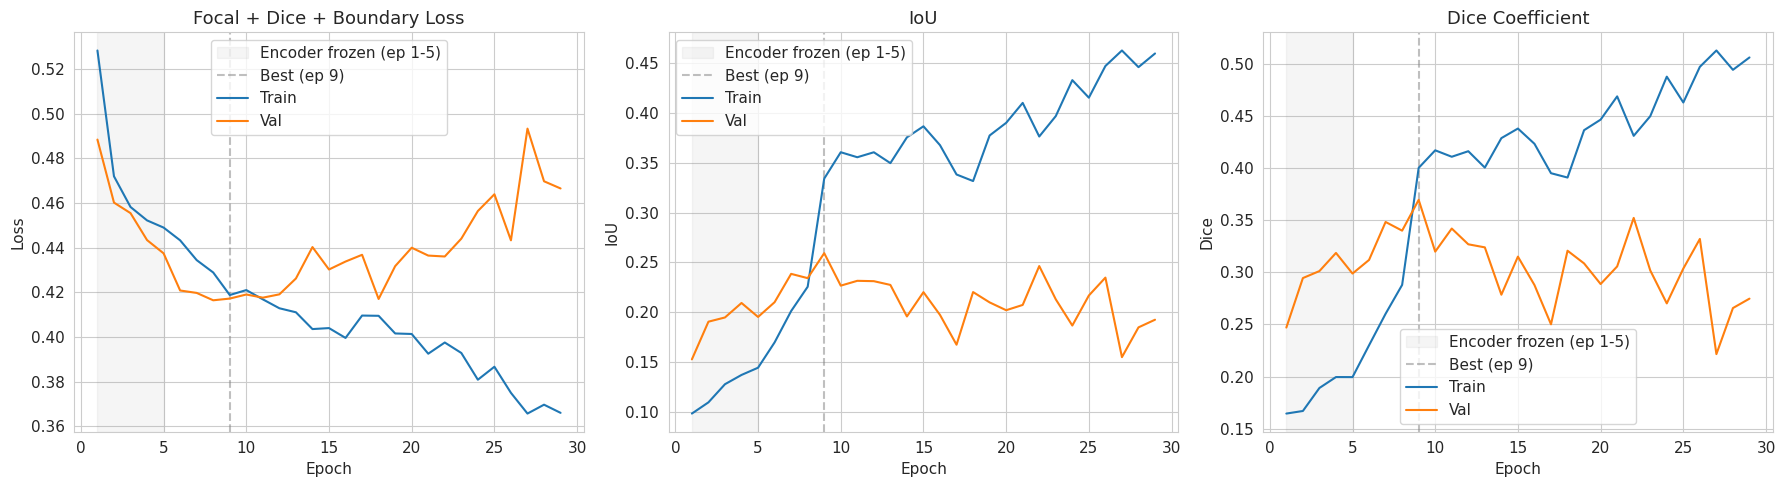

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, len(history["train_loss"]) + 1)

freeze_end = cfg.ENCODER_FREEZE_EPOCHS

for ax in axes:
    ax.axvspan(1, freeze_end, alpha=0.08, color="gray", label=f"Encoder frozen (ep 1-{freeze_end})")
    ax.axvline(best_epoch, color="gray", ls="--", alpha=0.5, label=f"Best (ep {best_epoch})")

# Loss
axes[0].plot(epochs_x, history["train_loss"], label="Train")
axes[0].plot(epochs_x, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Focal + Dice + Boundary Loss"); axes[0].legend()

# IoU
axes[1].plot(epochs_x, history["train_iou"], label="Train")
axes[1].plot(epochs_x, history["val_iou"],   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
axes[1].set_title("IoU"); axes[1].legend()

# Dice
axes[2].plot(epochs_x, history["train_dice"], label="Train")
axes[2].plot(epochs_x, history["val_dice"],   label="Val")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Dice")
axes[2].set_title("Dice Coefficient"); axes[2].legend()

plt.tight_layout(); plt.show()


# Phase 5: Test Evaluation + TTA

In [8]:
import torchvision.transforms.functional as TF

def tta_predict(model, image, device):
    """8-fold TTA: 4 rotations × 2 flips."""

    model.eval()
    preds = []
    with torch.no_grad():
        for k in range(4):
            for flip in [False, True]:
                x = TF.rotate(image, angle=90 * k)
                if flip:
                    x = TF.hflip(x)
                x = x.to(device)
                with autocast():
                    logit = model(x)
                prob = torch.sigmoid(logit)
                if flip:
                    prob = TF.hflip(prob)
                prob = TF.rotate(prob, angle=-90 * k)
                preds.append(prob.cpu())
    return torch.stack(preds).mean(dim=0)


ckpt = torch.load(os.path.join(cfg.CHECKPOINT_DIR, "best_model.pth"), map_location=cfg.DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']}")

# Standard evaluation
test_loss, test_m = validate(model, test_loader, criterion, cfg.DEVICE)
print(f"\nTest (standard) — blocks {cfg.TEST_BLOCKS}:")
print(f"  Loss:      {test_loss:.4f}")
print(f"  IoU:       {test_m['iou']:.4f}")
print(f"  Dice:      {test_m['dice']:.4f}")
print(f"  Precision: {test_m['precision']:.4f}")
print(f"  Recall:    {test_m['recall']:.4f}")

# TTA evaluation
print(f"\nRunning TTA (8×)...")
model.eval()
sums = {"iou": 0, "dice": 0, "prec": 0, "rec": 0}
n_tta = 0

for i in tqdm(range(len(test_ds)), desc="  TTA"):
    img, mask, _ = test_ds[i]
    prob  = tta_predict(model, img.unsqueeze(0), cfg.DEVICE)
    pred  = (prob > 0.5).float()
    mask_t = mask.unsqueeze(0)
    inter = (pred * mask_t).sum()
    p_sum = pred.sum(); t_sum = mask_t.sum()
    union = p_sum + t_sum - inter
    sums["iou"]  += (inter + 1e-7) / (union  + 1e-7)
    sums["dice"] += (2 * inter + 1e-7) / (p_sum + t_sum + 1e-7)
    sums["prec"] += (inter + 1e-7) / (p_sum + 1e-7)
    sums["rec"]  += (inter + 1e-7) / (t_sum + 1e-7)
    n_tta += 1

print(f"\nTest (TTA) — blocks {cfg.TEST_BLOCKS}:")
print(f"  IoU:       {sums['iou'] / n_tta:.4f}")
print(f"  Dice:      {sums['dice'] / n_tta:.4f}")
print(f"  Precision: {sums['prec'] / n_tta:.4f}")
print(f"  Recall:    {sums['rec'] / n_tta:.4f}")

print(f"\nPer-block (standard):")
for block_id in cfg.TEST_BLOCKS:
    bds = MelusiTileDataset(test_df[test_df["Block_id"] == block_id], cfg, transform=val_transform)
    bl  = DataLoader(bds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
    _, bm = validate(model, bl, criterion, cfg.DEVICE)
    print(f"  {block_id}: IoU={bm['iou']:.4f}  Dice={bm['dice']:.4f}  "
          f"Prec={bm['precision']:.4f}  Rec={bm['recall']:.4f}")


Loaded best model from epoch 9



Test (standard) — blocks ['block_1', 'block_11']:
  Loss:      0.4318
  IoU:       0.3505
  Dice:      0.4422
  Precision: 0.4092
  Recall:    0.7556

Running TTA (8×)...


  TTA: 100%|██████████| 703/703 [01:34<00:00,  7.45it/s]



Test (TTA) — blocks ['block_1', 'block_11']:
  IoU:       0.3652
  Dice:      0.4563
  Precision: 0.4284
  Recall:    0.7631

Per-block (standard):


  block_1: IoU=0.0879  Dice=0.1330  Prec=0.1135  Rec=0.8678


  block_11: IoU=0.3840  Dice=0.4782  Prec=0.4457  Rec=0.7496


## Prediction Overlays — Test Samples

In [9]:
import matplotlib.pyplot as plt

model.eval()
np.random.seed(42)
sample_idx = np.random.choice(len(test_ds), size=min(8, len(test_ds)), replace=False)

fig, axes = plt.subplots(len(sample_idx), 4, figsize=(20, 5 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = axes[np.newaxis, :]

for i, idx in enumerate(sample_idx):
    img, mask, boundary = test_ds[idx]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(cfg.DEVICE))
        pred   = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze()

    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array(cfg.IMG_STD) + np.array(cfg.IMG_MEAN)
    img_np = np.clip(img_np, 0, 1)
    mask_np = mask.squeeze().numpy()
    pred_np = pred.numpy()
    bnd_np  = boundary.squeeze().numpy()

    axes[i, 0].imshow(img_np); axes[i, 0].set_title("RGB")
    axes[i, 1].imshow(mask_np, cmap="Reds", vmin=0, vmax=1)
    axes[i, 1].imshow(bnd_np, cmap="Blues", alpha=0.3)
    axes[i, 1].set_title("GT (blue=boundary region)")
    axes[i, 2].imshow(pred_np, cmap="Blues", vmin=0, vmax=1); axes[i, 2].set_title("Prediction")

    overlay = np.zeros((*mask_np.shape, 3))
    overlay[..., 1] = pred_np * mask_np        # TP = green
    overlay[..., 0] = mask_np * (1 - pred_np)  # FN = red
    overlay[..., 2] = pred_np * (1 - mask_np)  # FP = blue
    axes[i, 3].imshow(img_np)
    axes[i, 3].imshow(overlay, alpha=0.5)
    axes[i, 3].set_title("TP(green) FN(red) FP(blue)")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout(); plt.show()


Output hidden; open in https://colab.research.google.com to view.

# Phase 6: Generate Dwelling Counts for RF Pipeline

In [10]:
model.eval()

all_tiles = pd.read_csv(cfg.TILE_INDEX)
all_tiles = all_tiles[all_tiles["has_mask"] == True].copy()

# Normalise block column
if "Block_id" in all_tiles.columns and "block_id" not in all_tiles.columns:
    all_tiles["block_id"] = all_tiles["Block_id"]
block_col = "Block_id" if "Block_id" in all_tiles.columns else "block_id"

all_ds = MelusiTileDataset(all_tiles, cfg, transform=val_transform)

print(f"Running TTA inference on {len(all_ds):,} tiles...")
pred_px = []
for i in tqdm(range(len(all_ds)), desc="TTA inference"):
    img, _, _ = all_ds[i]
    prob = tta_predict(model, img.unsqueeze(0), cfg.DEVICE)
    pred = (prob > 0.5).float()
    pred_px.append(pred.sum().item())

all_tiles["pred_dwelling_px"]   = pred_px[:len(all_tiles)]
all_tiles["pred_dwelling_frac"] = all_tiles["pred_dwelling_px"] / (cfg.TILE_SIZE ** 2)

block_summary = (
    all_tiles.groupby(block_col)
    .agg(
        n_tiles             = ("dwelling_pixel_count", "count"),
        label_dwelling_px   = ("dwelling_pixel_count", "sum"),
        pred_dwelling_px    = ("pred_dwelling_px",     "sum"),
    )
    .reset_index()
)
block_summary["label_area_m2"] = block_summary["label_dwelling_px"] * (cfg.PIXEL_SIZE ** 2)
block_summary["pred_area_m2"]  = block_summary["pred_dwelling_px"]  * (cfg.PIXEL_SIZE ** 2)
block_summary["ratio"] = (
    block_summary["pred_dwelling_px"] /
    block_summary["label_dwelling_px"].replace(0, np.nan)
)

print("\nBlock-level dwelling area:")
print(block_summary.to_string(index=False))

block_summary.to_csv(os.path.join(cfg.PROCESSED_DIR, "unet_run4_block_predictions.csv"), index=False)
all_tiles.to_csv(os.path.join(cfg.PROCESSED_DIR, "unet_run4_tile_predictions.csv"), index=False)
print(f"\nSaved: unet_run4_block_predictions.csv, unet_run4_tile_predictions.csv")

Running TTA inference on 8,109 tiles...


TTA inference: 100%|██████████| 8109/8109 [18:23<00:00,  7.35it/s]



Block-level dwelling area:
Block_id  n_tiles  label_dwelling_px  pred_dwelling_px  label_area_m2  pred_area_m2    ratio
 block_1       74             675156         3019970.0       607.6404     2717.9730 4.472996
block_10     1116           16816530        31741432.0     15134.8770    28567.2888 1.887514
block_11      629           14227185        28141711.0     12804.4665    25327.5399 1.978024
block_12     1619           19902975        32756121.0     17912.6775    29480.5089 1.645790
 block_2      408                  0         9289397.0         0.0000     8360.4573      NaN
 block_3      877                  0        20099732.0         0.0000    18089.7588      NaN
 block_4      870            2565313        10587870.0      2308.7817     9529.0830 4.127321
 block_5      402            6220408        13909812.0      5598.3672    12518.8308 2.236157
 block_6      782           15627700        28657976.0     14064.9300    25792.1784 1.833794
 block_7      422           10608246      

# Phase X: Save & Push

In [11]:
save_and_push("kc_unet.ipynb", "Run 4: fused SAM+GOB masks, all Run 3 fixes retained")

📋 Copied kc_unet.ipynb into repo
✅ Pushed kc_unet.ipynb to kc/unet
